## The effect of small perturbations of ECCM starting conditions on the resulting nadir brightness temperature spectrum

### Python imports

In [1]:
import numpy as np 
import scipy.constants as spc
import matplotlib.pyplot as plt 
from tqdm.auto import tqdm 

import sys
sys.path.append('..')
import eccm 
import mrtm

plt.style.use('~/Documents/Research/Akins.mplstyle')
%matplotlib widget

### Calculations for Saturn 

Deep ATM:   0%|          | 0/3 [00:00<?, ?it/s]

RH:   0%|          | 0/2 [00:00<?, ?it/s]

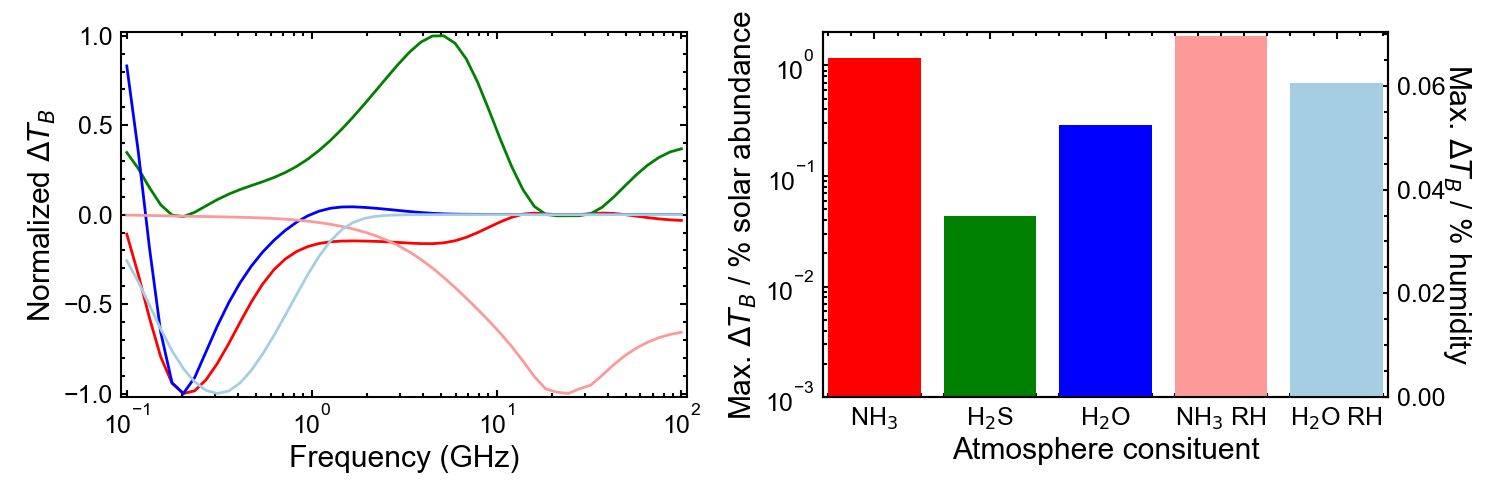

In [2]:
wave_cm = np.logspace(np.log10(0.3), np.log10(300), 50)  # One fn run takes 15s (30s for 100) 
freq_ghz = spc.c / (wave_cm * 1e-2) * 1e-9 
incang_deg = 0. 

step_gases = ['NH3', 'H2S', 'H2O']
rh_gases = ['NH3', 'H2O']
sg_psa = [1.48e-4, 2.89e-5, 1.07e-3]  # Solar ratios
label_dict = {'NH3': r'NH$_3$', 'H2S': r'H$_2$S','H2O': r'H$_2$O'}
paired_cmap = plt.get_cmap('Paired')
colors = ['r', 'g', 'b', paired_cmap(4), paired_cmap(0)]

p_grid = np.logspace(2, 9, 10000)
saturn_gravity = 10.44  # m/s2 
planet_radius = 60268  # km 

# Reference case
saturn_ro = np.loadtxt('../data/ro_profiles/saturn_cassini_schinder2011.txt', skiprows=3, delimiter=',')
saturn_pressure = saturn_ro[:, 0] * 1e2  # Pa
saturn_temperature = saturn_ro[:, 1]
gases1 = eccm.solar_to_deep_mole_fraction(10) 
gases2 = eccm.solar_to_deep_mole_fraction(3) 


deep_h2o = gases1['H2O']
deep_nh3 = gases2['NH3']
deep_h2s = gases1['H2S']
deep_ch4 = gases1['CH4']
deep_ph3 = gases1['PH3']


pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 deep_h2o, deep_nh3, deep_h2s, deep_ch4, deep_ph3, 0.88, 0.12,
                                                 nh3_rh = 0.7, h2o_rh = 0.7,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ref_spec = Tup 
this_jac_list = [] 

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
tax = axs[1].twinx()

for j, sg in enumerate(tqdm(step_gases, desc='Deep ATM')):
    if sg == 'NH3': 
        use_deep_nh3 = deep_nh3 + 1e-2 * sg_psa[0]
        use_deep_h2s = deep_h2s 
        use_deep_h2o = deep_h2o
    elif sg == 'H2S': 
        use_deep_nh3 = deep_nh3 
        use_deep_h2s = deep_h2s + 1e-2 * sg_psa[1]
        use_deep_h2o = deep_h2o
    else: 
        use_deep_nh3 = deep_nh3 
        use_deep_h2s = deep_h2s 
        use_deep_h2o = deep_h2o + 1e-2 * sg_psa[2]

    pressure_grid, temperature_grid, altitude_grid, \
    x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
    a_h2osolid, a_h2oliquid, a_h2osolution, \
    a_nh3solid, a_nh3liquid, \
    a_h2ssolid, a_h2sliquid, \
    a_nh4sh, c_nh3h2o, \
    a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                     use_deep_h2o, use_deep_nh3, use_deep_h2s, deep_ch4, deep_ph3, 0.88, 0.12,
                                                     nh3_rh=0.7, h2o_rh=0.7, latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

    full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
    this_jac = (Tup - ref_spec) / 1e-2 
    this_jac_list.append(this_jac.copy()) 

for j, rhg in enumerate(tqdm(rh_gases, desc='RH')):
    if rhg == 'NH3': 
        use_nh3_rh = 0.7 + 1e-2 
        use_h2o_rh = 0.7 
    else: 
        use_nh3_rh = 0.7 
        use_h2o_rh = 0.7 + 1e-2 
    pressure_grid, temperature_grid, altitude_grid, \
    x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
    a_h2osolid, a_h2oliquid, a_h2osolution, \
    a_nh3solid, a_nh3liquid, \
    a_h2ssolid, a_h2sliquid, \
    a_nh4sh, c_nh3h2o, \
    a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                     deep_h2o, deep_nh3, deep_h2s, deep_ch4, deep_ph3, 0.88, 0.12,
                                                     nh3_rh=use_nh3_rh, h2o_rh=use_h2o_rh, latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)
    full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
    this_jac = (Tup - ref_spec) / 1e-2 
    this_jac_list.append(this_jac.copy()) 

for j, tj in enumerate(this_jac_list): 
    if j < 3: 
        use_label = label_dict[step_gases[j]]
        axs[1].bar(use_label, np.max(abs(tj)) * 1e-2 , color=colors[j], label=use_label)
    else:
        use_label = label_dict[rh_gases[j - 3]] + ' RH' 
        tax.bar(use_label, np.max(abs(tj)) * 1e-2 , color=colors[j], label=use_label)
    axs[0].semilogx(freq_ghz, tj / np.max(abs(tj)), color=colors[j], label=use_label)
        
axs[0].set_xlabel('Frequency (GHz)')
axs[0].set_ylabel(r'Normalized $\Delta T_B$')
axs[1].set_xlabel('Atmosphere consituent')
axs[1].set_ylabel(r'Max. $\Delta T_B$ / % solar abundance')
tax.set_ylabel(r'Max. $\Delta T_B$ / % humidity', rotation=-90, labelpad=20)
# axs[0].legend()
axs[1].set_yscale('log')
axs[1].set_ylim(1e-3, 2)

fig.tight_layout()    
fig.savefig('saturn_dTB.png')

### Calculations for Uranus 

Deep ATM:   0%|          | 0/3 [00:00<?, ?it/s]

RH:   0%|          | 0/2 [00:00<?, ?it/s]

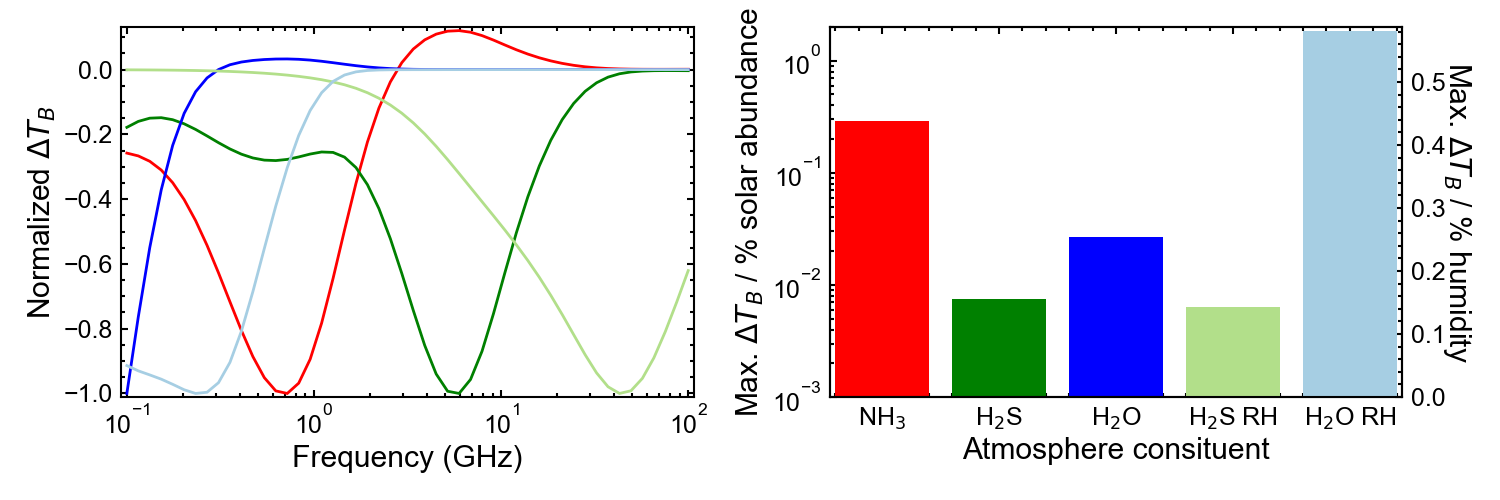

In [3]:
wave_cm = np.logspace(np.log10(0.3), np.log10(300), 50)  # One fn run takes 15s (30s for 100) 
freq_ghz = spc.c / (wave_cm * 1e-2) * 1e-9 
incang_deg = 0. 

step_gases = ['NH3', 'H2S', 'H2O']
rh_gases = ['H2S', 'H2O']
sg_psa = [1.48e-4, 2.89e-5, 1.07e-3]  # Solar ratios
label_dict = {'NH3': r'NH$_3$', 'H2S': r'H$_2$S','H2O': r'H$_2$O'}
paired_cmap = plt.get_cmap('Paired')
colors = ['r', 'g', 'b', paired_cmap(2), paired_cmap(0)]

p_grid = np.logspace(2, 9, 10000)
uranus_gravity = 8.87  # m/s2 
planet_radius = 25559  # km 

# Reference case
uranus_ro = np.loadtxt('../data/ro_profiles/uranus_voyager2_lindal1987.txt', skiprows=3, delimiter=',')
uranus_pressure = uranus_ro[:, 0] * 1e2  # Pa
uranus_temperature = uranus_ro[:, 1]
gases1 = eccm.solar_to_deep_mole_fraction(35) 
gases2 = eccm.solar_to_deep_mole_fraction(50) 
gases3 = eccm.solar_to_deep_mole_fraction(1) 

deep_h2o = gases1['H2O']
deep_nh3 = gases3['NH3']
deep_h2s = gases1['H2S']
deep_ch4 = gases2['CH4']


pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases1['H2O'], gases3['NH3'], gases1['H2S'], gases2['CH4'], 0., 0.85, 0.15,
                                                 h2s_rh=0.35, h2o_rh=0.35, latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ref_spec = Tup 
this_jac_list = [] 

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
tax = axs[1].twinx()

for j, sg in enumerate(tqdm(step_gases, desc='Deep ATM')):
    if sg == 'NH3': 
        use_deep_nh3 = deep_nh3 + 1e-2 * sg_psa[0]
        use_deep_h2s = deep_h2s 
        use_deep_h2o = deep_h2o
    elif sg == 'H2S': 
        use_deep_nh3 = deep_nh3 
        use_deep_h2s = deep_h2s + 1e-2 * sg_psa[1]
        use_deep_h2o = deep_h2o
    else: 
        use_deep_nh3 = deep_nh3 
        use_deep_h2s = deep_h2s 
        use_deep_h2o = deep_h2o + 1e-2 * sg_psa[2]

    pressure_grid, temperature_grid, altitude_grid, \
    x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
    a_h2osolid, a_h2oliquid, a_h2osolution, \
    a_nh3solid, a_nh3liquid, \
    a_h2ssolid, a_h2sliquid, \
    a_nh4sh, c_nh3h2o, \
    a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                     use_deep_h2o, use_deep_nh3, use_deep_h2s, deep_ch4, 0., 0.85, 0.15,
                                                     h2s_rh=0.35, h2o_rh=0.35, latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

    full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
    this_jac = (Tup - ref_spec) / 1e-2 
    this_jac_list.append(this_jac.copy()) 

for j, rhg in enumerate(tqdm(rh_gases, desc='RH')):
    if rhg == 'H2S': 
        use_h2s_rh = 0.35 + 1e-2 
        use_h2o_rh = 0.35 
    else: 
        use_h2s_rh = 0.35 
        use_h2o_rh = 0.35 + 1e-2 
    pressure_grid, temperature_grid, altitude_grid, \
    x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
    a_h2osolid, a_h2oliquid, a_h2osolution, \
    a_nh3solid, a_nh3liquid, \
    a_h2ssolid, a_h2sliquid, \
    a_nh4sh, c_nh3h2o, \
    a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                     deep_h2o, deep_nh3, deep_h2s, deep_ch4, 0., 0.85, 0.15,
                                                     h2s_rh=use_h2s_rh, h2o_rh=use_h2o_rh, latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)
    full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
    this_jac = (Tup - ref_spec) / 1e-2 
    this_jac_list.append(this_jac.copy()) 

for j, tj in enumerate(this_jac_list): 
    if j < 3: 
        use_label = label_dict[step_gases[j]]
        axs[1].bar(use_label, np.max(abs(tj)) * 1e-2 , color=colors[j], label=use_label)
    else:
        use_label = label_dict[rh_gases[j - 3]] + ' RH' 
        tax.bar(use_label, np.max(abs(tj)) * 1e-2 , color=colors[j], label=use_label)
    axs[0].semilogx(freq_ghz, tj / np.max(abs(tj)), color=colors[j], label=use_label)
        
axs[0].set_xlabel('Frequency (GHz)')
axs[0].set_ylabel(r'Normalized $\Delta T_B$')
axs[1].set_xlabel('Atmosphere consituent')
axs[1].set_ylabel(r'Max. $\Delta T_B$ / % solar abundance')
tax.set_ylabel(r'Max. $\Delta T_B$ / % humidity', rotation=-90, labelpad=20)
# axs[0].legend()
axs[1].set_yscale('log')
axs[1].set_ylim(1e-3, 2)

fig.tight_layout()    
fig.savefig('uranus_dTB.png')
    
